# Практическое занятие №5: Визуализация данных с Matplotlib и Seaborn

## Вариант 10: Attention (время реакции)

Датасет: ```sns.load_dataset('attention')```

Задачи:
1. Построить boxplot времени реакции по типу внимания.
2. Построить violinplot времени реакции по типу задания.
3. Построить линейный график среднего времени реакции по решению
(solution) для каждого типа внимания.
4. Построить pairplot для числовых признаков, если они есть.

### Импорт библиотек

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

/home/ub/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


### Загрузка данных

In [16]:
# Загрузка данных
df = sns.load_dataset('attention')

# Просмотр первых строк
print(df.head())

# Информация о структуре датасета
print(df.info())

# Проверка пропусков
print(df.isnull().sum())

   Unnamed: 0  subject attention  solutions  score
0           0        1   divided          1    2.0
1           1        2   divided          1    3.0
2           2        3   divided          1    3.0
3           3        4   divided          1    5.0
4           4        5   divided          1    4.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  60 non-null     int64  
 1   subject     60 non-null     int64  
 2   attention   60 non-null     object 
 3   solutions   60 non-null     int64  
 4   score       60 non-null     float64
dtypes: float64(1), int64(3), object(1)
memory usage: 2.5+ KB
None
Unnamed: 0    0
subject       0
attention     0
solutions     0
score         0
dtype: int64


## Преобразования

In [18]:
# Проверка дубликатов
print("Количество дубликатов:", df.duplicated().sum())

# Удаление дубликатов
df = df.drop_duplicates()

# Проверка типов данных
print(df.dtypes)

Количество дубликатов: 0
Unnamed: 0      int64
subject         int64
attention      object
solutions       int64
score         float64
dtype: object


## 1. Boxplot времени реакции по типу внимания

График показывает распределение времени реакции для разных типов внимания.
С помощью boxplot можно определить медиану, разброс данных и возможные выбросы.

/tmp/ipykernel_36447/3039546221.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='attention', y='score', palette='Set2')


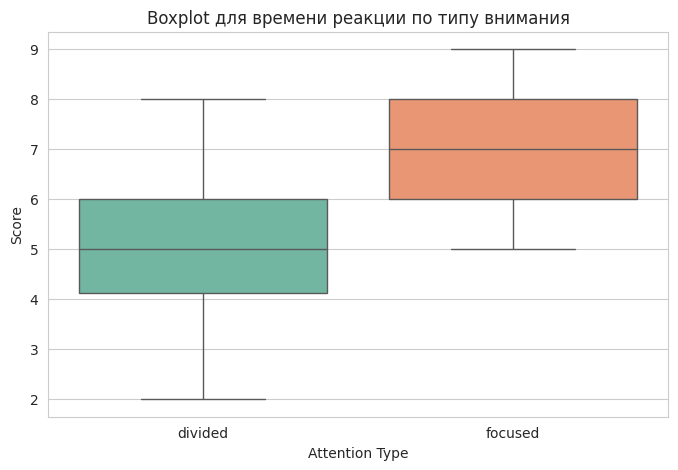

In [5]:
plt.figure(figsize=(8, 5))

# Ящик с усами для времени реакции по типу внимания
sns.boxplot(data=df, x='attention', y='score', palette='Set2')

# Заголовок графика
plt.title('Boxplot для времени реакции по типу внимания')
# Название оси x
plt.xlabel('Attention Type')

# Название оси y
plt.ylabel('Score')

plt.show()

### Вывод
При focused attention результаты в среднем выше, чем при divided attention.
Медиана score у focused attention составляет около 7, тогда как у divided - около 5. Отличия в разбросе данных не наблюдаются

## 2. Violinplot времени реакции по типу задания

Violinplot показывает распределение score для разных solutions.
График позволяет оценить плотность распределения данных.

/tmp/ipykernel_36447/1474694825.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot (data=df, x='solutions', y='score', palette='Pastel1')


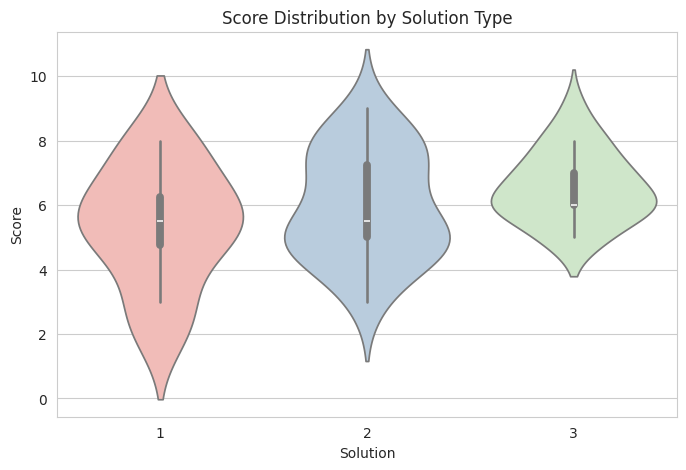

In [ ]:
plt.figure(figsize=(8, 5))

# Скрипичный график времени реакции по типу задания
sns.violinplot (data=df, x='solutions', y='score', palette='Pastel1')

plt.title('Скрипичный график времени реакции по типу задания')
plt.xlabel('Solution')
plt.ylabel('Score')

plt.show()

### Вывод

Для разных типов заданий распределение score отличается.
Некоторые solutions имеют более широкий разброс значений, например:

Для solution 1 значения score распределены достаточно широко — примерно от 2 до 8.
Наибольшая плотность данных наблюдается около 5–6, что видно по расширению графика в центральной части.
Нижний и верхний хвосты показывают наличие редких низких и высоких значений.
Медиана score равна около 5.

### 3. Линейный график среднего времени реакции по решению (solution) для каждого типа внимания

График показывает изменение среднего score
для каждого типа внимания в зависимости от solution.

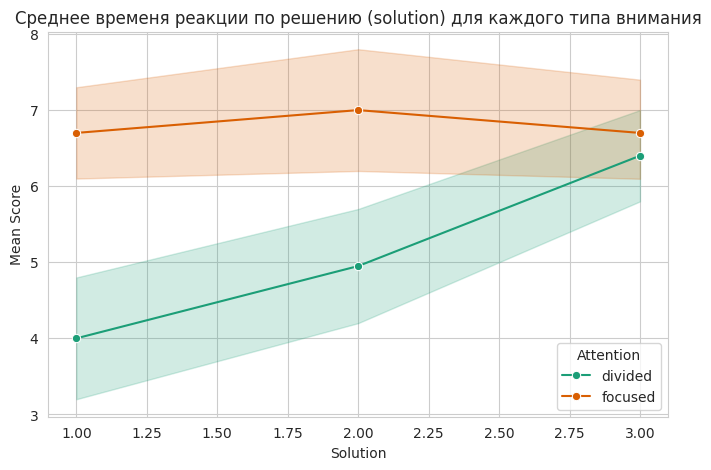

In [12]:
plt.figure(figsize=(8, 5))

# Линейный график среднего времени реакции по решению для типов внимания
sns.lineplot (data=df, x='solutions', y='score', hue='attention', marker='o', palette='Dark2')

plt.title('Среднее временя реакции по решению (solution) для каждого типа внимания')
plt.xlabel('Solution')
plt.ylabel('Mean Score')

plt.legend(title='Attention')

plt.show()

### Вывод

Для focused attention средние значения score выше, чем для divided attention, почти для всех solutions.

У divided attention наблюдается заметный рост среднего score от solution 1 к solution 3.
Для focused attention значения остаются более стабильными и изменяются незначительно.
Наибольшая разница между типами внимания наблюдается при solution 1.

К solution 3 значения среднего score для двух типов внимания становятся ближе и сходятся примерно на уровне 6.5.

### 4. Pairplot для числовых признаков.

Pairplot показывает взаимосвязи между числовыми признаками.

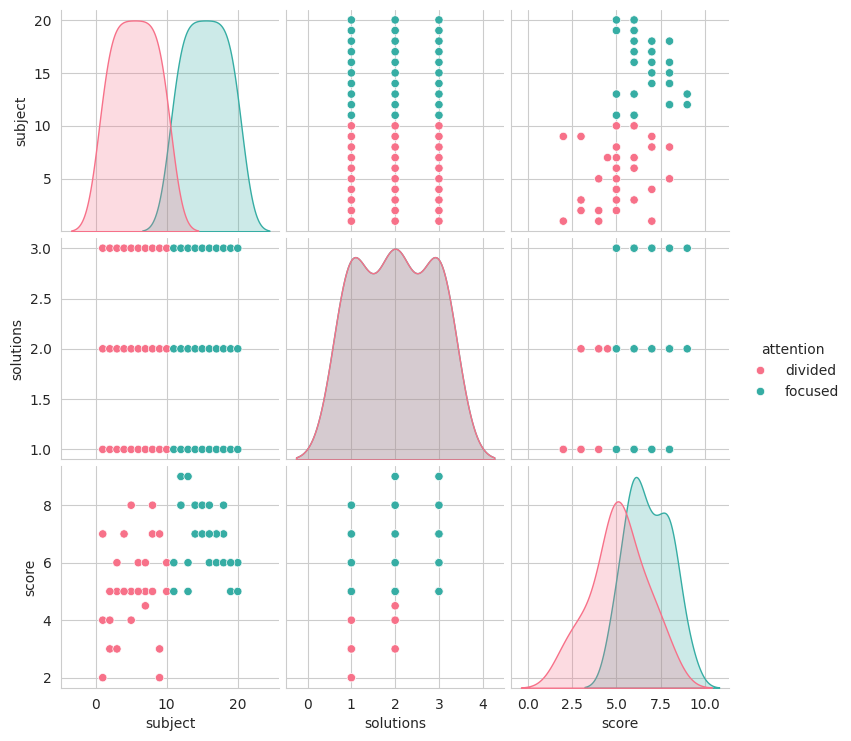

In [15]:
sns.pairplot (df, hue='attention', palette='husl')
plt.show()

### Вывод
Для focused attention значения score в среднем выше и сосредоточены в диапазоне 6–8, тогда как для divided attention чаще встречаются значения score около 5.
Для разных типов внимания наблюдаются явные различия в распределении score.

# Общий вывод

В ходе работы были построены различные типы графиков для анализа датасета attention с использованием библиотек Matplotlib и Seaborn.
В процессе визуализации были исследованы распределения score, различия между типами внимания и особенности результатов для разных solutions.

Анализ показал, что для focused attention значения score в среднем выше, чем для divided attention.
Наиболее заметные различия между группами наблюдаются на boxplot и lineplot.
Violinplot показал особенности распределения данных и различия в плотности значений score для разных solutions.

Сильных линейных зависимостей между числовыми признаками обнаружено не было, однако различия в распределении score для разных типов внимания визуально заметны.

В результате работа позволила освоить основные методы визуализации данных и применить их для анализа данных.